In [3]:
import sys
print(sys.executable)

c:\Users\DELL\AppData\Local\Python\pythoncore-3.12-64\python.exe


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
df = pd.read_csv("../data/scam_job_postings.csv")

In [7]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [8]:
print(df.shape)
print(df.columns.tolist())

(17880, 18)
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [8]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [10]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percent
})

missing_df.sort_values(
    "Percentage",
    ascending=False
)

,Missing Values,Percentage
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7212,40.335570
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2696,15.078300


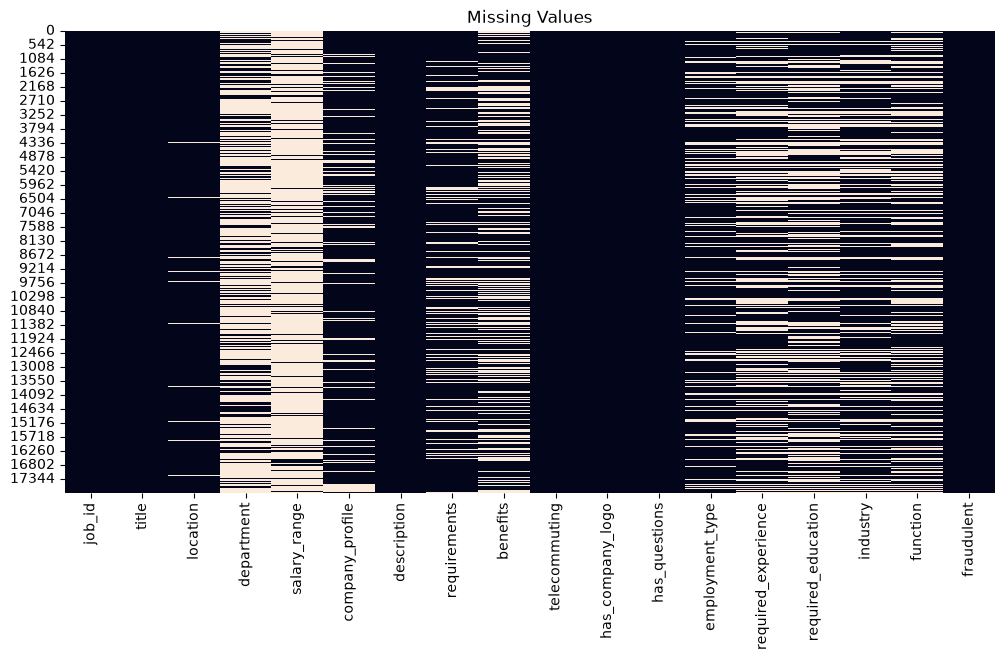

In [12]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [15]:
df.fraudulent.value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [15]:
df["fraudulent"].value_counts(normalize=True) * 100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

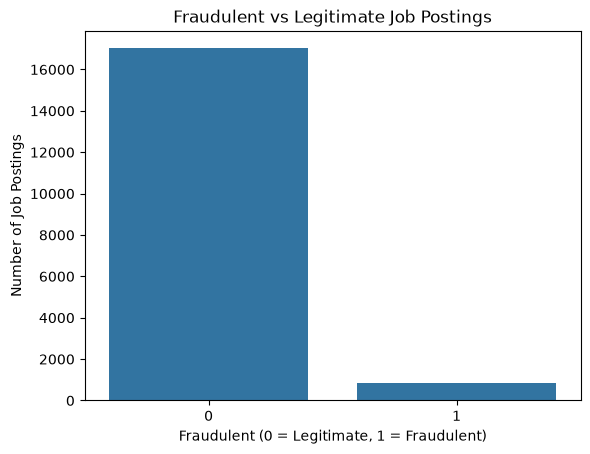

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="fraudulent")

plt.title("Fraudulent vs Legitimate Job Postings")
plt.xlabel("Fraudulent (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Number of Job Postings")
plt.show()

In [17]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

In [18]:
for col in text_columns:
    df[col + "_length"] = df[col].fillna("").str.len()

In [19]:
df[
    [
        "title_length",
        "company_profile_length",
        "description_length",
        "requirements_length",
        "benefits_length"
    ]
].describe()

,title_length,company_profile_length,description_length,requirements_length,benefits_length
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,28.530313,620.901454,1218.004418,590.132215,208.895694
std,13.871256,567.454100,894.828620,613.191270,337.077357
min,3.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,138.000000,607.000000,146.000000,0.000000
50%,25.000000,570.000000,1017.000000,467.000000,45.000000
75%,35.000000,879.000000,1586.000000,820.000000,294.000000
max,142.000000,6178.000000,14907.000000,10864.000000,4429.000000


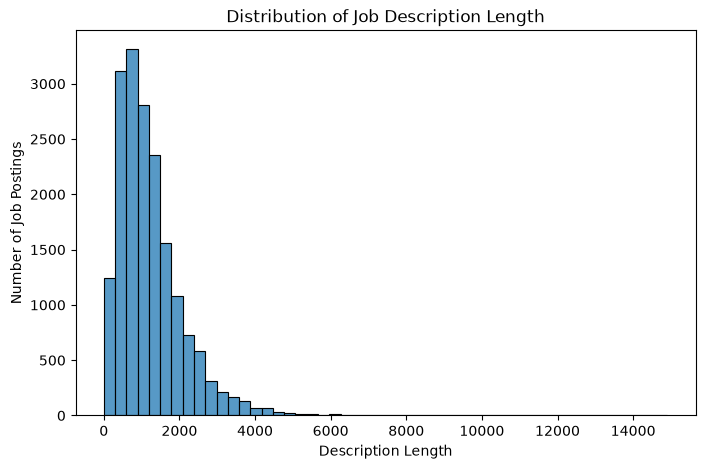

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="description_length",
    bins=50
)

plt.title("Distribution of Job Description Length")
plt.xlabel("Description Length")
plt.ylabel("Number of Job Postings")

plt.show()

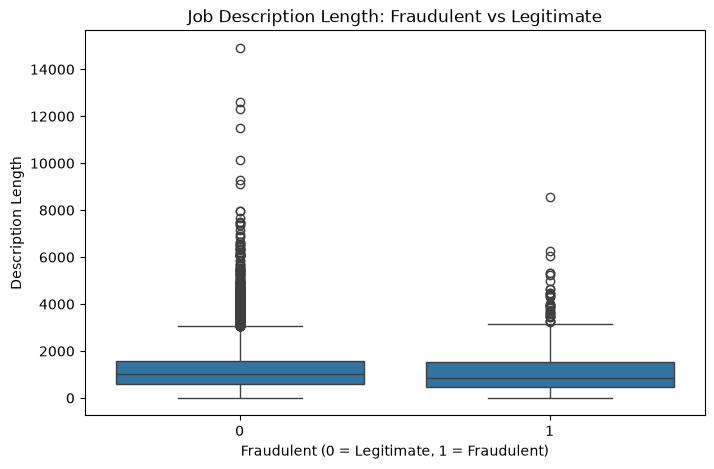

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fraudulent",
    y="description_length"
)

plt.title("Job Description Length: Fraudulent vs Legitimate")
plt.xlabel("Fraudulent (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Description Length")

plt.show()

In [22]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

df["combined_text"] = (
    df[text_columns]
    .fillna("")
    .agg(" ".join, axis=1)
)

In [23]:
df[["title", "combined_text", "fraudulent"]].head()

,title,combined_text,fraudulent
0,Marketing Intern,"Marketing Intern We're Food52, and we've creat...",0
1,Customer Service - Cloud Video Production,Customer Service - Cloud Video Production 90 S...,0
2,Commissioning Machinery Assistant (CMA),Commissioning Machinery Assistant (CMA) Valor ...,0
3,Account Executive - Washington DC,Account Executive - Washington DC Our passion ...,0
4,Bill Review Manager,Bill Review Manager SpotSource Solutions LLC i...,0


In [24]:
from collections import Counter
import re

In [25]:
def get_words(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())
    return words

In [26]:
scam_text = df[df["fraudulent"] == 1]["combined_text"]

scam_words = []

for text in scam_text:
    scam_words.extend(get_words(text))

scam_word_counts = Counter(scam_words)

scam_word_counts.most_common(20)

[('and', 13826),
 ('to', 7710),
 ('the', 6693),
 ('of', 4888),
 ('a', 4403),
 ('in', 4322),
 ('with', 3316),
 ('for', 3235),
 ('is', 2021),
 ('we', 1956),
 ('you', 1912),
 ('work', 1775),
 ('are', 1764),
 ('experience', 1602),
 ('or', 1563),
 ('on', 1476),
 ('our', 1427),
 ('as', 1421),
 ('be', 1326),
 ('skills', 1170)]

In [27]:
legit_text = df[df["fraudulent"] == 0]["combined_text"]

legit_words = []

for text in legit_text:
    legit_words.extend(get_words(text))

legit_word_counts = Counter(legit_words)

legit_word_counts.most_common(20)

[('and', 351396),
 ('to', 202820),
 ('the', 198392),
 ('of', 149681),
 ('a', 142356),
 ('in', 125500),
 ('with', 88896),
 ('for', 81800),
 ('we', 78082),
 ('our', 65846),
 ('is', 62389),
 ('you', 59949),
 ('are', 44723),
 ('on', 40264),
 ('as', 40040),
 ('be', 38371),
 ('experience', 37899),
 ('or', 36014),
 ('work', 35510),
 ('that', 34515)]

In [3]:
import sys

!{sys.executable} -m pip install nltk

  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 4.2 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 3.5 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.8 MB/s eta 0:00:00
Using cached click-8.4.2-py3-none-any.whl (119 kB)
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("Stopwords loaded:", len(stop_words))

Stopwords loaded: 198


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
from collections import Counter
import re
import pandas as pd 
import numpy as np


df = pd.read_csv("../data/scam_job_postings.csv")

print(df.shape)

(17880, 18)


In [33]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

df["combined_text"] = (
    df[text_columns]
    .fillna("")
    .agg(" ".join, axis=1)
)

In [34]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("Stopwords loaded:", len(stop_words))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


Stopwords loaded: 198


[nltk_data]   Package stopwords is already up-to-date!


In [35]:
from collections import Counter
import re
def get_meaningful_words(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())

    return [
        word for word in words
        if word not in stop_words
    ]

In [36]:
scam_words = []

for text in df[df["fraudulent"] == 1]["combined_text"]:
    scam_words.extend(get_meaningful_words(text))

scam_word_counts = Counter(scam_words)

print("Top 20 Words in Fraudulent Jobs:")
print(scam_word_counts.most_common(20))

Top 20 Words in Fraudulent Jobs:
[('work', 1775), ('experience', 1602), ('skills', 1170), ('amp', 1154), ('team', 856), ('company', 856), ('time', 823), ('service', 735), ('management', 730), ('business', 721), ('customer', 710), ('position', 679), ('ability', 653), ('data', 651), ('engineering', 633), ('project', 606), ('services', 582), ('required', 572), ('industry', 570), ('new', 552)]


In [37]:
legit_words = []

for text in df[df["fraudulent"] == 0]["combined_text"]:
    legit_words.extend(get_meaningful_words(text))

legit_word_counts = Counter(legit_words)

print("Top 20 Words in Legitimate Job Postings:")
print(legit_word_counts.most_common(20))

Top 20 Words in Legitimate Job Postings:
[('experience', 37899), ('work', 35510), ('team', 33270), ('business', 21533), ('company', 21514), ('skills', 18397), ('new', 17446), ('customer', 17284), ('management', 16211), ('sales', 16059), ('development', 15727), ('working', 15472), ('amp', 15459), ('services', 15146), ('time', 14821), ('service', 13911), ('years', 12958), ('people', 12799), ('us', 12623), ('marketing', 12541)]


In [38]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

def preprocess_words(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())

    words = [
        word for word in words
        if word not in stop_words
    ]

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return words

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [39]:
print(preprocess_words(
    "Jobs running companies hiring employees"
))

['job', 'running', 'company', 'hiring', 'employee']


In [40]:
scam_words = []

for text in df[df["fraudulent"] == 1]["combined_text"]:
    scam_words.extend(preprocess_words(text))

scam_word_counts = Counter(scam_words)

print("Top 20 words in fraudulent jobs:")
print(scam_word_counts.most_common(20))

Top 20 words in fraudulent jobs:
[('work', 1835), ('experience', 1613), ('service', 1317), ('skill', 1254), ('amp', 1154), ('customer', 1084), ('company', 969), ('team', 964), ('position', 931), ('product', 926), ('time', 892), ('project', 855), ('business', 773), ('system', 765), ('management', 730), ('year', 711), ('ability', 695), ('data', 651), ('engineering', 633), ('job', 624)]


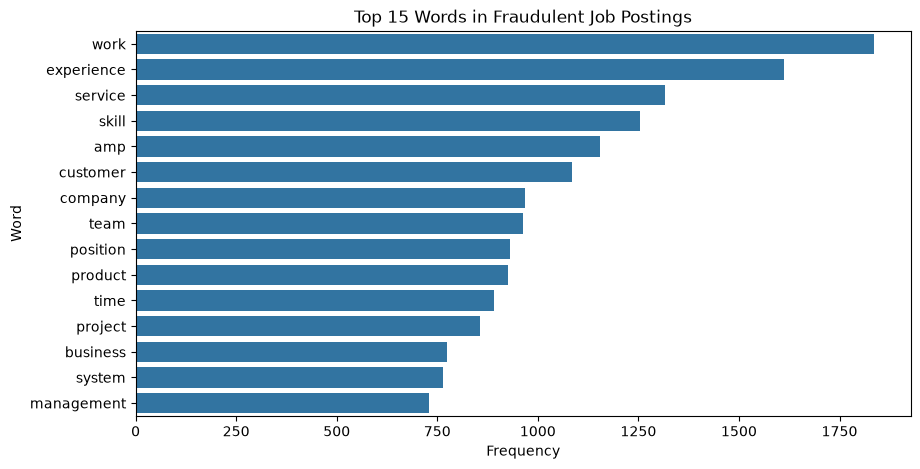

In [41]:
top_scam = scam_word_counts.most_common(15)

words = [item[0] for item in top_scam]
counts = [item[1] for item in top_scam]

plt.figure(figsize=(10, 5))
sns.barplot(x=counts, y=words)

plt.title("Top 15 Words in Fraudulent Job Postings")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

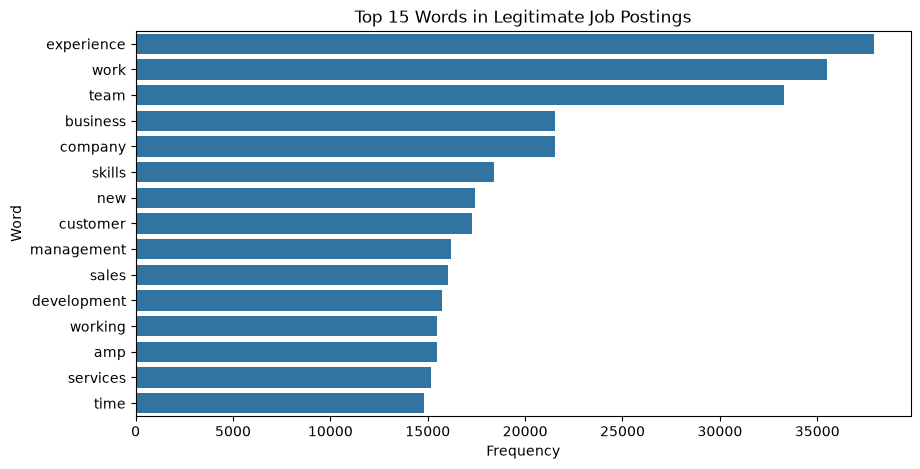

In [42]:
top_legit = legit_word_counts.most_common(15)

words = [item[0] for item in top_legit]
counts = [item[1] for item in top_legit]

plt.figure(figsize=(10, 5))
sns.barplot(x=counts, y=words)

plt.title("Top 15 Words in Legitimate Job Postings")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [43]:
!{sys.executable} -m pip install wordcloud

'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [44]:
import sys
print(sys.executable)

c:\Users\DELL\AppData\Local\Python\pythoncore-3.12-64\python.exe


In [45]:
from wordcloud import WordCloud

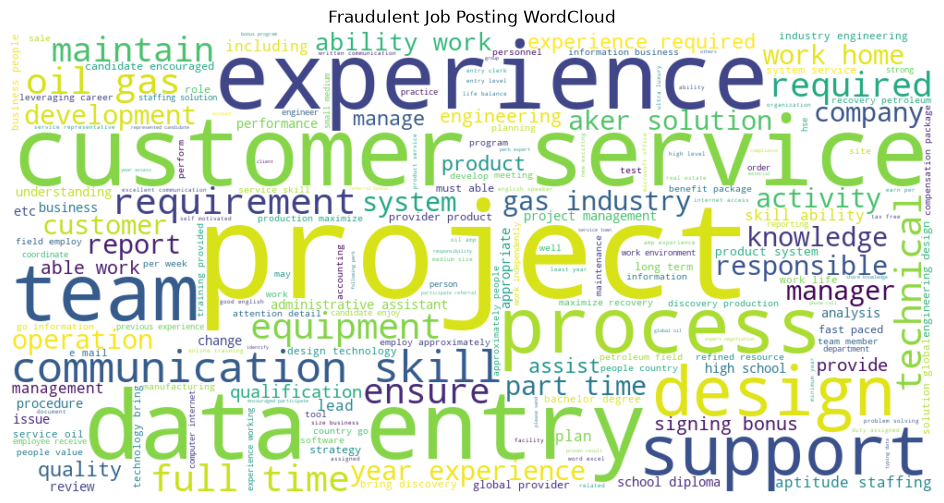

In [46]:
scam_text = " ".join(scam_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(scam_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Fraudulent Job Posting WordCloud")
plt.show()

In [47]:
def clean_text(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())

    words = [
        word for word in words
        if word not in stop_words
    ]

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [48]:
df["clean_text"] = df["combined_text"].apply(clean_text)

In [49]:
df[["combined_text", "clean_text", "fraudulent"]].head()

,combined_text,clean_text,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",marketing intern created groundbreaking award ...,0
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...,0
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...,0
3,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...,0
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solution llc gl...,0


In [51]:
import sys

!{sys.executable} -m pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl (8.2 MB)
   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
    --------------------------------------- 0.8/36.7 MB 4.8 MB/s eta 0:00:08
   - -------------------------------------- 1.3/36.7 MB 4.2 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/36.7 MB 4.1 MB/s eta 0:00:09
   ---- ----------------------------------- 3.7/36.7 MB 4.4 MB/s eta 0:00:08
   ----- ---------------------------------- 4.7/36.7 MB 4.5 MB/s eta 0:00:08
   ------ --------------------------------- 5.5/36.7 MB 4.5 MB/s eta 0:00:07
   ------- -------------------------------- 6.6/36.7 MB 4.6 MB/s eta 0:00:07
   -------- ------------------------------- 7.9/36.7 MB 4.7 MB/s eta 0:00:07
   --------- ------------------------------ 8.9/36.7 MB 4.7 MB/s eta 0:00:06
   ---------- ----------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14304
Testing samples: 3576


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [54]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

In [55]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [56]:
X_test_tfidf = tfidf.transform(X_test)

In [57]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (14304, 10000)
Testing TF-IDF shape: (3576, 10000)


In [58]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['aan' 'abc' 'abc supply' 'ability' 'ability adapt' 'ability build'
 'ability communicate' 'ability create' 'ability deliver'
 'ability demonstrate' 'ability develop' 'ability effectively'
 'ability facilitate' 'ability function' 'ability grow' 'ability handle'
 'ability interact' 'ability lead' 'ability learn' 'ability lift'
 'ability make' 'ability manage' 'ability meet' 'ability multi'
 'ability pas' 'ability present' 'ability prioritize' 'ability provide'
 'ability quickly' 'ability read' 'ability required' 'ability take'
 'ability think' 'ability travel' 'ability understand' 'ability use'
 'ability work' 'ability write' 'able' 'able communicate'
 'able demonstrate' 'able effectively' 'able handle' 'able lift'
 'able manage' 'able multi' 'able pas' 'able perform' 'able provide'
 'able take']


In [59]:
print(X_train_tfidf.shape)
print(X_train_tfidf[0])

(14304, 10000)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 377 stored elements and shape (1, 10000)>
  Coords	Values
  (0, 1797)	0.040250443189813113
  (0, 1253)	0.09308267673413287
  (0, 7352)	0.04671194216122207
  (0, 9014)	0.3004013309756078
  (0, 3435)	0.11963108499145207
  (0, 1446)	0.02316857631529951
  (0, 3015)	0.020383566408359702
  (0, 4418)	0.02848966112114083
  (0, 7020)	0.02581855299522081
  (0, 7015)	0.031231969120879485
  (0, 7960)	0.03325583401211438
  (0, 7488)	0.04661417931885889
  (0, 4481)	0.03749550986562223
  (0, 1830)	0.020371948902888917
  (0, 9228)	0.022576784081308213
  (0, 2547)	0.029405035595854404
  (0, 1983)	0.08983295115276432
  (0, 7888)	0.061820879100240526
  (0, 6983)	0.035040523736516636
  (0, 4355)	0.0707575262593151
  (0, 1786)	0.0862483750460771
  (0, 6092)	0.023536324519005086
  (0, 5619)	0.06679762919850335
  (0, 678)	0.03161557344400099
  (0, 3449)	0.03369460835573232
  :	:
  (0, 4842)	0.03794624874464539
  (0, 1596)	0.03777352

In [60]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr_model.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [61]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [62]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Legitimate", "Fraudulent"]
))

Accuracy: 0.9748322147651006
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99      3403
  Fraudulent       0.69      0.88      0.77       173

    accuracy                           0.97      3576
   macro avg       0.84      0.93      0.88      3576
weighted avg       0.98      0.97      0.98      3576



In [63]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [64]:
from sklearn.metrics import accuracy_score, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Legitimate", "Fraudulent"]
    )
)

Naive Bayes Accuracy: 0.9588926174496645
              precision    recall  f1-score   support

  Legitimate       0.97      0.99      0.98      3403
  Fraudulent       0.64      0.34      0.45       173

    accuracy                           0.96      3576
   macro avg       0.80      0.67      0.71      3576
weighted avg       0.95      0.96      0.95      3576



In [65]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced"
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

In [66]:
from sklearn.metrics import accuracy_score, classification_report

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Legitimate", "Fraudulent"]
    )
)

SVM Accuracy: 0.9860178970917226
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3403
  Fraudulent       0.86      0.84      0.85       173

    accuracy                           0.99      3576
   macro avg       0.93      0.92      0.92      3576
weighted avg       0.99      0.99      0.99      3576



In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm
}

for model_name, predictions in models_predictions.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.974832,0.687783,0.878613,0.771574
1,Naive Bayes,0.958893,0.641304,0.341040,0.445283
2,SVM,0.986018,0.863905,0.843931,0.853801


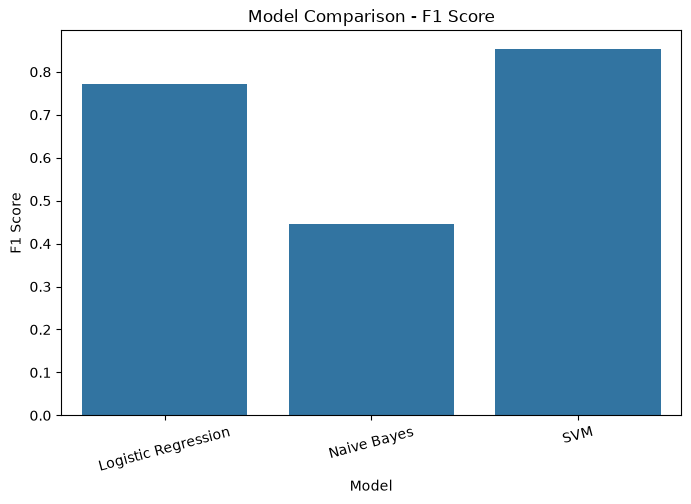

In [68]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Model")

plt.xticks(rotation=15)
plt.show()

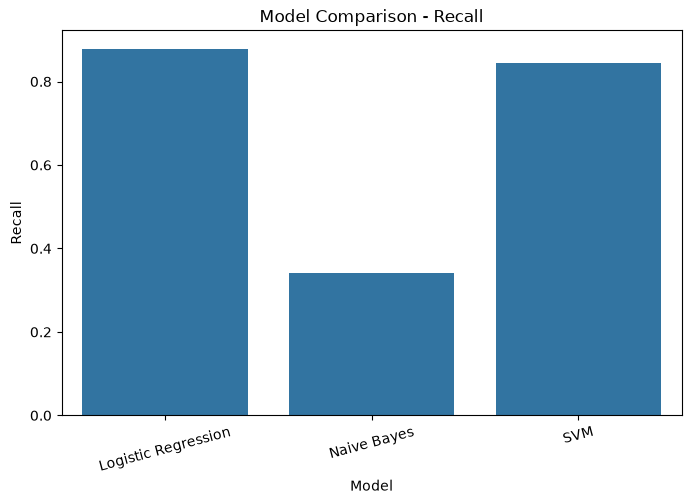

In [69]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall"
)

plt.title("Model Comparison - Recall")
plt.ylabel("Recall")
plt.xlabel("Model")

plt.xticks(rotation=15)
plt.show()

In [70]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.974832,0.687783,0.878613,0.771574
1,Naive Bayes,0.958893,0.641304,0.341040,0.445283
2,SVM,0.986018,0.863905,0.843931,0.853801


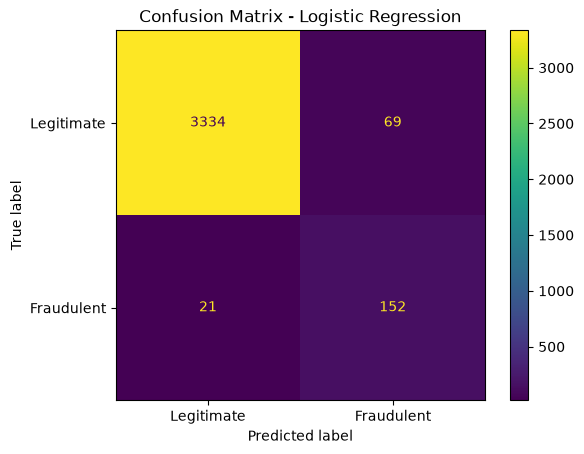

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Legitimate", "Fraudulent"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

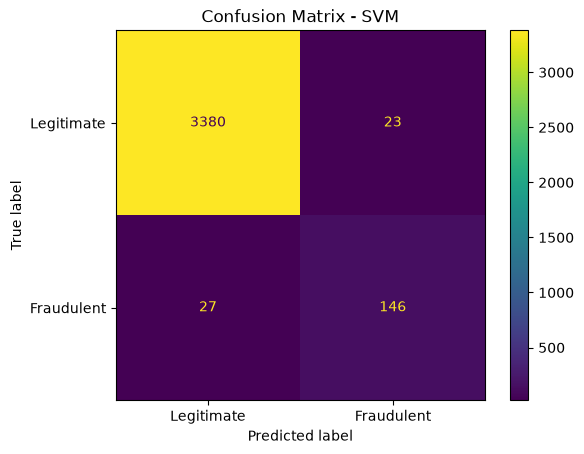

In [72]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Legitimate", "Fraudulent"]
)

disp.plot()

plt.title("Confusion Matrix - SVM")
plt.show()

In [73]:
best_model = lr_model

In [74]:
new_job = """
Earn ₹80,000 per month working from home.
No experience required.
Pay ₹2,000 registration fee to receive your appointment letter.
Apply immediately and secure your position.
"""

In [75]:
new_job_clean = clean_text(new_job)

print(new_job_clean)

earn per month working home experience required pay registration fee receive appointment letter apply immediately secure position


In [76]:
new_job_tfidf = tfidf.transform([new_job_clean])

In [77]:
prediction = lr_model.predict(new_job_tfidf)

print("Prediction:", prediction)

Prediction: [1]


In [78]:
if prediction[0] == 1:
    print("🚨 FRAUDULENT JOB POSTING")
else:
    print("✅ LEGITIMATE JOB POSTING")

🚨 FRAUDULENT JOB POSTING


In [79]:
probability = lr_model.predict_proba(new_job_tfidf)

print(probability)

[[0.13543282 0.86456718]]


In [80]:
fraud_probability = probability[0][1]

print(
    f"Fraud Probability: {fraud_probability * 100:.2f}%"
)

Fraud Probability: 86.46%


In [81]:
risk_score = fraud_probability * 100

print(f"Risk Score: {risk_score:.2f}/100")

Risk Score: 86.46/100


In [82]:
if risk_score < 30:
    risk_level = "LOW"
elif risk_score < 60:
    risk_level = "MEDIUM"
elif risk_score < 80:
    risk_level = "HIGH"
else:
    risk_level = "CRITICAL"

print("Risk Level:", risk_level)

Risk Level: CRITICAL


In [83]:
test_jobs = [
    """
    We are looking for a software developer with 2 years
    of experience. Please attend an interview on Monday.
    """,

    """
    Earn ₹80,000 per month from home.
    No experience required. Pay ₹2,000 registration fee
    immediately to get your job offer.
    """,

    """
    Marketing Manager required. Bachelor's degree required.
    Apply through our official company careers page.
    """
]

In [84]:
for job in test_jobs:

    cleaned = clean_text(job)
    vectorized = tfidf.transform([cleaned])

    prediction = lr_model.predict(vectorized)[0]
    probability = lr_model.predict_proba(vectorized)[0][1]

    print("=" * 60)

    if prediction == 1:
        print("Prediction: FRAUDULENT")
    else:
        print("Prediction: LEGITIMATE")

    print(f"Fraud Probability: {probability * 100:.2f}%")

Prediction: LEGITIMATE
Fraud Probability: 6.17%
Prediction: FRAUDULENT
Fraud Probability: 87.57%
Prediction: LEGITIMATE
Fraud Probability: 29.21%


In [85]:
def predict_job(job_text):

    # 1. Clean text
    cleaned_text = clean_text(job_text)

    # 2. Convert to TF-IDF
    job_tfidf = tfidf.transform([cleaned_text])

    # 3. Prediction
    prediction = lr_model.predict(job_tfidf)[0]

    # 4. Fraud probability
    probability = lr_model.predict_proba(job_tfidf)[0][1]

    # 5. Risk score
    risk_score = probability * 100

    # 6. Risk level
    if risk_score < 30:
        risk_level = "LOW"
    elif risk_score < 60:
        risk_level = "MEDIUM"
    elif risk_score < 80:
        risk_level = "HIGH"
    else:
        risk_level = "CRITICAL"

    return prediction, probability, risk_score, risk_level

In [86]:
job = """
Earn ₹80,000 per month working from home.
No experience required.
Pay ₹2,000 registration fee to receive your appointment letter.
Apply immediately.
"""

prediction, probability, risk_score, risk_level = predict_job(job)

print("Prediction:", "FRAUDULENT" if prediction == 1 else "LEGITIMATE")
print(f"Fraud Probability: {probability * 100:.2f}%")
print(f"Risk Score: {risk_score:.2f}/100")
print("Risk Level:", risk_level)

Prediction: FRAUDULENT
Fraud Probability: 89.20%
Risk Score: 89.20/100
Risk Level: CRITICAL


In [87]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(lr_model, "../models/scam_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!
